# Trabalho Prático 1 - Ciência de Dados
Feito por Leonardo de Paula Hernandes Pedro    RA: 241023092

## Datasets Utilizados:
Primary completion rate, female (% of relevant age group),  
disponível em: https://data.worldbank.org/indicator/SE.PRM.CMPT.FE.ZS

Primary completion rate, male (% of relevant age group),  
disponível em: https://databank.worldbank.org/metadataglossary/gender-statistics/series/SE.PRM.CMPT.MA.ZS

## Introdução
A educação primária constitui a base do desenvolvimento humano e social, sendo um direito fundamental reconhecido internacionalmente.  
O acesso universal a esse nível de ensino é essencial não apenas para a alfabetização e aquisição de habilidades básicas, mas também  
para a promoção de melhores condições de saúde, participação cidadã e oportunidades econômicas ao longo da vida.


Nesse cenário, esse trabalho busca compreender como o acesso e a permanência na escola se distribuem entre diferentes regiões e países,  
destacando as diferenças entre o gênero masculino e feminino, tal qual sua evolução ao longo do período de análise.

## Objetivos

Este estudo tem como objetivo analisar a evolução da taxa de conclusão da educação primária feminina em diferentes países  
e regiões do mundo no século XXI. A partir da integração e tratamento de bases de dados internacionais, busca-se compreender  
não apenas os níveis de acesso à educação, mas também a distribuição desse acesso entre diferentes contextos socioeconômicos  
e geográficos. 

O trabalho procura responder a questões centrais como: em que medida a taxa de conclusão feminina difere da  
masculina nos países com piores indicadores; Se há evidências de instabilidade nas trajetórias educacionais associadas a crises  
políticas ou humanitárias; qual período recente apresentou maior avanço na educação feminina; e como fatores como nível de renda  
e localização regional influenciam tanto o progresso quanto a desigualdade educacional. Além disso, investiga-se a existência  
de disparidades internas entre países de uma mesma região, contribuindo para uma compreensão mais granular do fenômeno.

# 1. Tratamento de dados

1.1. Imports

In [245]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

1.2. Carregar os dados e classificar entre países ou regiões de agregados

In [246]:
female_df = pd.read_csv("./API_SE.PRM.CMPT.FE.ZS_DS2_en_csv_v2_8339.csv", skiprows=4)
male_df = pd.read_csv("./API_SE.PRM.CMPT.MA.ZS_DS2_en_csv_v2_9106.csv", skiprows=4)

# Carregar metadados de países
female_meta = pd.read_csv("./Metadata_Country_API_SE.PRM.CMPT.FE.ZS_DS2_en_csv_v2_8339.csv")
male_meta = pd.read_csv("./Metadata_Country_API_SE.PRM.CMPT.MA.ZS_DS2_en_csv_v2_9106.csv")
# Classificação entre região agregada ou país
def classificar(row):
    if pd.isna(row["Region"]):
        return "Aggregated"
    else:
        return "Country"

female_meta["Type"] = female_meta.apply(classificar, axis=1)
male_meta["Type"] = male_meta.apply(classificar, axis=1)

# Merge com dataset principal
female_df = female_df.merge(female_meta[["Country Code", "Region", "IncomeGroup", "Type"]], on="Country Code", how="left")
male_df = male_df.merge(male_meta[["Country Code", "Region", "IncomeGroup", "Type"]], on="Country Code", how="left")

1.3. Remover colunas desnecessárias e visualizar estrutura inicial

In [247]:
female_df = female_df.drop(columns=["Indicator Name", "Indicator Code", "Unnamed: 70"], errors='ignore')
male_df = male_df.drop(columns=["Indicator Name", "Indicator Code", "Unnamed: 70"], errors='ignore')
display(female_df)

,Country Name,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2019,2020,2021,2022,2023,2024,2025,Region,IncomeGroup,Type
0,Aruba,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,106.547623,100.597908,98.522903,91.962914,NaN,NaN,NaN,Latin America & Caribbean,High income,Country
1,Africa Eastern and Southern,AFE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,69.208900,70.187447,71.491768,70.935730,70.536232,70.651451,NaN,NaN,NaN,Aggregated
2,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,69.613503,NaN,NaN,NaN,NaN,NaN,NaN,Middle East & North Africa,Low income,Country
3,Africa Western and Central,AFW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,63.415619,63.838902,64.598618,63.442539,64.203979,64.423950,NaN,NaN,NaN,Aggregated
4,Angola,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,59.423173,NaN,48.818884,NaN,NaN,Sub-Saharan Africa,Lower middle income,Country
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Europe & Central Asia,Upper middle income,Country
262,"Yemen, Rep.",YEM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Middle East & North Africa,Low income,Country
263,South Africa,ZAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,94.498350,93.852200,95.611453,94.839370,94.495150,NaN,NaN,Sub-Saharan Africa,Upper middle income,Country
264,Zambia,ZMB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sub-Saharan Africa,Lower middle income,Country


In [248]:
display(male_df)

,Country Name,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2019,2020,2021,2022,2023,2024,2025,Region,IncomeGroup,Type
0,Aruba,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,98.382751,104.499268,87.798042,93.241173,NaN,NaN,NaN,Latin America & Caribbean,High income,Country
1,Africa Eastern and Southern,AFE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,70.102074,71.407242,72.086014,71.248772,70.348778,70.416992,NaN,NaN,NaN,Aggregated
2,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,107.201797,NaN,NaN,NaN,103.277351,NaN,NaN,Middle East & North Africa,Low income,Country
3,Africa Western and Central,AFW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,69.191910,69.261719,69.792877,68.559273,68.599327,68.797440,NaN,NaN,NaN,Aggregated
4,Angola,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,60.625765,NaN,46.897584,NaN,NaN,Sub-Saharan Africa,Lower middle income,Country
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Europe & Central Asia,Upper middle income,Country
262,"Yemen, Rep.",YEM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Middle East & North Africa,Low income,Country
263,South Africa,ZAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,91.558845,91.482844,94.833113,99.350667,96.163884,NaN,NaN,Sub-Saharan Africa,Upper middle income,Country
264,Zambia,ZMB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sub-Saharan Africa,Lower middle income,Country


1.4. Identificar colunas de anos

In [249]:
female_year_columns = [col for col in female_df.columns if col.isdigit()]
male_year_columns = [col for col in male_df.columns if col.isdigit()]

1.5. Converter para formato numérico

In [250]:
female_df[female_year_columns] = female_df[female_year_columns].apply(pd.to_numeric, errors='coerce')
male_df[male_year_columns] = male_df[male_year_columns].apply(pd.to_numeric, errors='coerce')

1.6. Tratar inconsistências

In [251]:
#Valores válidos: Entre 0 e 100
female_df[female_year_columns] = female_df[female_year_columns].clip(lower=0, upper=100)
male_df[male_year_columns] = male_df[male_year_columns].clip(lower=0, upper=100)

1.7. Determinar anos considerados para período de análise

In [252]:
# Porcentagem de dados não nulos por ano
f_not_null_data = female_df[female_year_columns].notna().mean()
m_not_null_data = male_df[male_year_columns].notna().mean()
print(f_not_null_data, "\n")
print(m_not_null_data)

1960    0.000000
1961    0.000000
1962    0.000000
1963    0.000000
1964    0.000000
          ...   
2021    0.687970
2022    0.672932
2023    0.654135
2024    0.432331
2025    0.037594
Length: 66, dtype: float64 

1960    0.000000
1961    0.000000
1962    0.000000
1963    0.000000
1964    0.000000
          ...   
2021    0.680451
2022    0.672932
2023    0.669173
2024    0.548872
2025    0.041353
Length: 66, dtype: float64


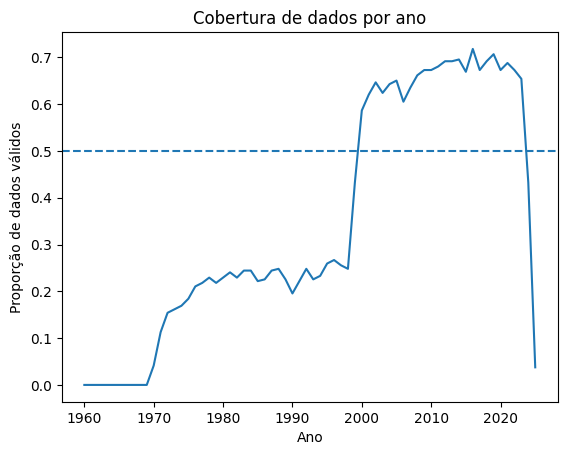

In [253]:
#Definir mínimo de dados para ser considerado válido
f_min_data = female_df[female_year_columns].notna().mean()

valid_years = f_min_data[f_min_data >= 0.5].index

f_min_data.plot()
plt.axhline(0.5, linestyle='--')
plt.title("Cobertura de dados por ano")
plt.ylabel("Proporção de dados válidos")
plt.xlabel("Ano")
plt.show()

In [254]:
# Filtrar apenas os anos válidos
female_df_filtered = female_df[
    ["Country Name", "Country Code", "Region", "IncomeGroup"] + list(valid_years)
]

male_df_filtered = male_df[
    ["Country Name", "Country Code", "Region", "IncomeGroup"] + list(valid_years)
]
print("Anos válidos:", valid_years)


Anos válidos: Index(['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008',
       '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017',
       '2018', '2019', '2020', '2021', '2022', '2023'],
      dtype='str')


In [255]:
female_df_long = female_df_filtered.melt(
    id_vars=["Country Name", "Country Code", "Region", "IncomeGroup"],
    value_vars=valid_years,
    var_name="Year",
    value_name="Completion Rate"
)

male_df_long = male_df_filtered.melt(
    id_vars=["Country Name", "Country Code", "Region", "IncomeGroup"],
    value_vars=valid_years,
    var_name="Year",
    value_name="Completion Rate"
)

female_df_long["Year"] = female_df_long["Year"].astype(int)
male_df_long["Year"] = male_df_long["Year"].astype(int)

1.8. Preencher dados faltantes

In [256]:
#Via interpolação para preencher lacunas de até três anos consecutivos:
female_df_long = female_df_long.sort_values(["Country Code", "Year"])
male_df_long = male_df_long.sort_values(["Country Code", "Year"])


female_df_long["Completion Rate"] = female_df_long.groupby("Country Code")["Completion Rate"].transform(
    lambda x: x.interpolate(method="linear", limit=3, limit_direction="both")
)

male_df_long["Completion Rate"] = male_df_long.groupby("Country Code")["Completion Rate"].transform(
    lambda x: x.interpolate(method="linear", limit=3, limit_direction="both")
)

#Via preenchimento pela média do país caso ainda haja lacunas:
female_country_mean = female_df_long.groupby("Country Code")["Completion Rate"].transform("mean")
male_country_mean = male_df_long.groupby("Country Code")["Completion Rate"].transform("mean")

female_df_long["Completion Rate"] = female_df_long["Completion Rate"].fillna(female_country_mean)
male_df_long["Completion Rate"] = male_df_long["Completion Rate"].fillna(male_country_mean)

#Drop, caso ainda haja lacunas:
female_df_long = female_df_long.dropna(subset=["Completion Rate"])
male_df_long = male_df_long.dropna(subset=["Completion Rate"])

1.9 Verificação final do tratamento dos dados

In [257]:
print("\nResumo após limpeza:")
print("Dados inválidos - Tabela feminina:")
print(female_df_long["Completion Rate"].isna().sum())
print("\nDados inválidos - Tabela masculina:")
print(male_df_long["Completion Rate"].isna().sum())

print(female_df_long.head())
female_df_long.groupby("Region")["Completion Rate"].describe()


Resumo após limpeza:
Dados inválidos - Tabela feminina:
0

Dados inválidos - Tabela masculina:
0
     Country Name Country Code                     Region  IncomeGroup  Year  \
0           Aruba          ABW  Latin America & Caribbean  High income  2000   
266         Aruba          ABW  Latin America & Caribbean  High income  2001   
532         Aruba          ABW  Latin America & Caribbean  High income  2002   
798         Aruba          ABW  Latin America & Caribbean  High income  2003   
1064        Aruba          ABW  Latin America & Caribbean  High income  2004   

      Completion Rate  
0           93.215736  
266         93.215736  
532        100.000000  
798         95.614037  
1064        93.931030  


,count,mean,std,min,25%,50%,75%,max
Region,,,,,,,,
East Asia & Pacific,696.0,94.050065,9.120182,45.072990,92.625475,97.452032,100.000000,100.0
Europe & Central Asia,1176.0,96.590321,5.540095,60.514019,96.105980,98.551498,100.000000,100.0
Latin America & Caribbean,888.0,93.476499,7.801594,49.859509,90.100504,95.965890,100.000000,100.0
Middle East & North Africa,504.0,85.156900,17.602399,33.446362,74.585504,94.064209,98.499828,100.0
North America,72.0,98.116232,1.575022,89.655167,97.227517,98.283958,98.837222,100.0
South Asia,144.0,88.662305,14.382971,49.788631,77.906508,95.932164,100.000000,100.0
Sub-Saharan Africa,1128.0,63.079382,23.108375,12.187710,48.388069,63.508089,82.322195,100.0


# 2. Desenvolvimento de análises

2.1 Criar um dataset geral, fundindo o masculino e feminino

In [258]:
# Merge masculino + feminino
merged_df = pd.merge(
    female_df_long,
    male_df_long,
    on=["Country Name", "Country Code", "Region", "IncomeGroup", "Year"],
    how="inner"
)

# Renomear colunas de conclusão
merged_df = merged_df.rename(columns={
    "Completion Rate_x": "Female Completion Rate",
    "Completion Rate_y": "Male Completion Rate"
})

# Criar coluna de gap de gênero
merged_df["Gender Gap"] = (
    merged_df["Male Completion Rate"] - merged_df["Female Completion Rate"]
)

2.2 Listar países com a pior taxa de conclusão da educação primária entre mulheres

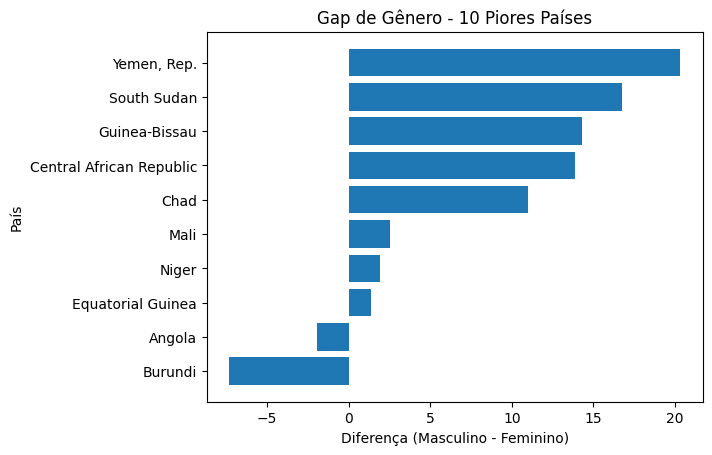

In [259]:
# Último ano disponível
latest_year = merged_df["Year"].max()

df_latest = merged_df[merged_df["Year"] == latest_year]

# Top 10 piores (menor taxa feminina)
worst_10 = df_latest.nsmallest(10, "Female Completion Rate")
worst_10 = worst_10.sort_values("Gender Gap")
plt.figure()
plt.barh(worst_10["Country Name"], worst_10["Gender Gap"])
plt.title("Gap de Gênero - 10 Piores Países")
plt.xlabel("Diferença (Masculino - Feminino)")
plt.ylabel("País")
plt.show()

## Atenção: 
Apesar do gap de gênero ser negativo em Burundi e Angola, outras fontes indicam que a alfabetização nesses países também é maior entre homens, o que pode indicar imprecisões no dataset ou no tratamento de dados.

Fonte: https://knowledgehub.adeanet.org/en/country-profiles/burundi#:~:text=Literacy%20rate%20by%20sex%20(2022):%201%20*,*%20Males:%2081.84%25%20*%20Females:%2069.44%20%25

# 2.3 Países com maior desigualdade

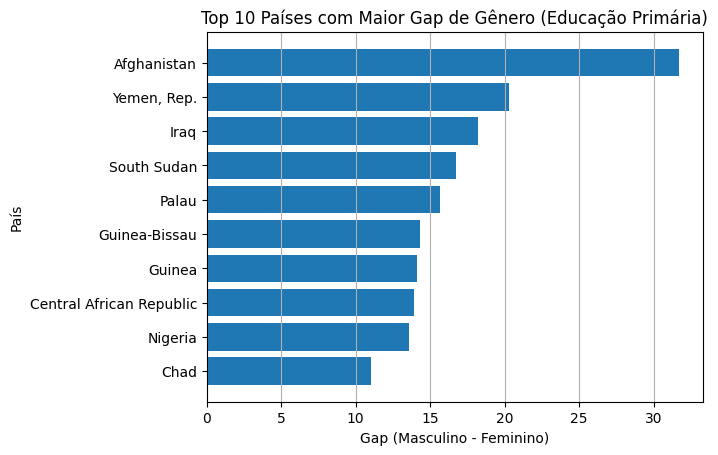

In [260]:
top_gap = (
    df_latest
    .sort_values("Gender Gap", ascending=False)
    .head(10)
)

top_gap = top_gap.sort_values("Gender Gap")

plt.figure()

plt.barh(top_gap["Country Name"], top_gap["Gender Gap"])

plt.title("Top 10 Países com Maior Gap de Gênero (Educação Primária)")
plt.xlabel("Gap (Masculino - Feminino)")
plt.ylabel("País")

plt.grid(axis='x')

plt.show()

## É importante notar que:

Vários desses países enfrentam crises humanitárias decorrentes de guerras civis ou externas, ou do fundamentalismo religioso e autoritarismo político.

O Afeganistão, que lidera o ranking com sobras, é governado pelo grupo Talibã desde 2021, e é o país que mais possui restrições severas contra o acesso à educação por mulheres,

sendo proibido o acesso ao ensino secundário e superior. Outros países fortemente influenciados pelo islamismo desincentivam a introdução de mulheres à educação

# 2.4 Comparação de períodos (2000–2010 vs 2010–2020)

In [261]:
# Média global por ano
global_trend = merged_df.groupby("Year")["Female Completion Rate"].mean().reset_index()

# Crescimento por período
growth_1 = global_trend[
    (global_trend["Year"] >= 2000) & (global_trend["Year"] <= 2010)
]

growth_2 = global_trend[
    (global_trend["Year"] >= 2010) & (global_trend["Year"] <= 2020)
]

accel_1 = growth_1["Female Completion Rate"].iloc[-1] - growth_1["Female Completion Rate"].iloc[0]
accel_2 = growth_2["Female Completion Rate"].iloc[-1] - growth_2["Female Completion Rate"].iloc[0]

print("Crescimento 2000–2010:", accel_1)
print("Crescimento 2010–2020:", accel_2)

Crescimento 2000–2010: 6.489382189311414
Crescimento 2010–2020: 1.1301769022825425


# 2.5 Evolução da média global

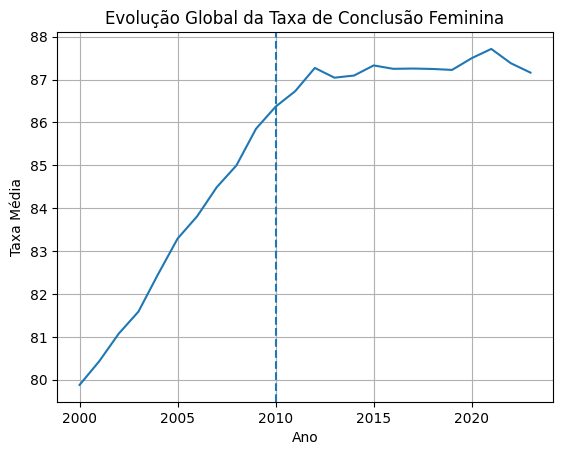

In [262]:
plt.figure()
plt.plot(global_trend["Year"], global_trend["Female Completion Rate"])

# Linhas verticais para separar períodos
plt.axvline(x=2010, linestyle='--')

plt.title("Evolução Global da Taxa de Conclusão Feminina")
plt.xlabel("Ano")
plt.ylabel("Taxa Média")
plt.grid(True)

plt.show()

Insight: Vários países em desenvolvimento aumentaram sua taxa de alfabetização geral de forma acelerada até o início da décda de 2010, com o crescimento se estabilizando desde então.

# 2.6 Evolução por grupos de renda

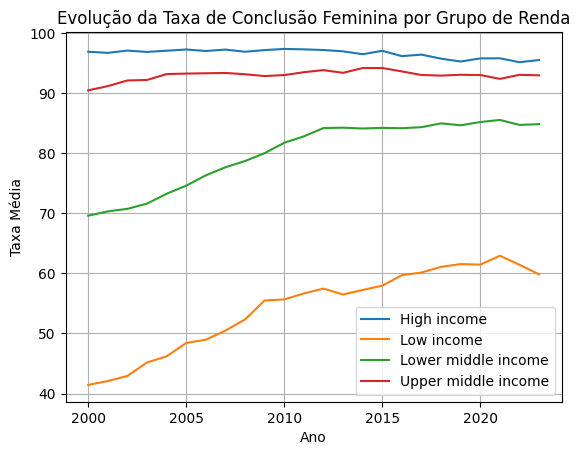

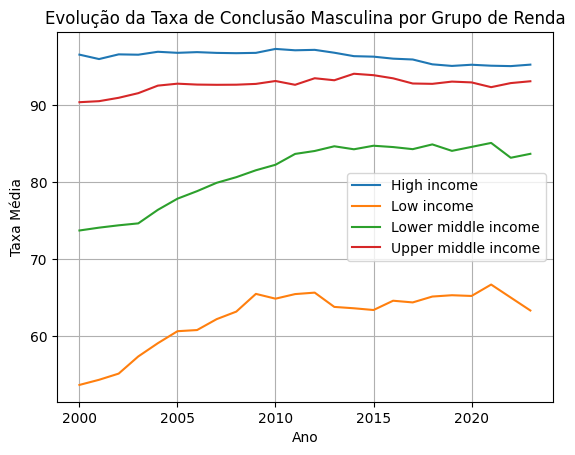

In [264]:
income_factor = merged_df.groupby(["Year", "IncomeGroup"])["Female Completion Rate"].mean().reset_index()

plt.figure()

for group in income_factor["IncomeGroup"].unique():
    df_plot = income_factor[income_factor["IncomeGroup"] == group]
    plt.plot(df_plot["Year"], df_plot["Female Completion Rate"], label=group)

plt.title("Evolução da Taxa de Conclusão Feminina por Grupo de Renda")
plt.xlabel("Ano")
plt.ylabel("Taxa Média")
plt.legend()
plt.grid(True)

plt.show()

income_factor = merged_df.groupby(["Year", "IncomeGroup"])["Male Completion Rate"].mean().reset_index()

plt.figure()

for group in income_factor["IncomeGroup"].unique():
    df_plot = income_factor[income_factor["IncomeGroup"] == group]
    plt.plot(df_plot["Year"], df_plot["Male Completion Rate"], label=group)

plt.title("Evolução da Taxa de Conclusão Masculina por Grupo de Renda")
plt.xlabel("Ano")
plt.ylabel("Taxa Média")
plt.legend()
plt.grid(True)

plt.show()

## Note que:
O nível de renda é o principal fator que influencia na taxa de alfabetização de países, para ambos os gêneros. 
    
Presume-se que as regiões mais pobres não oferecem instituições de ensino adequadas e acessíveis, e a condição das famílias provoca evasão escolar e recorrência ao trabalho infantil

# 2.7 Gráfico de Gap de gênero X Renda

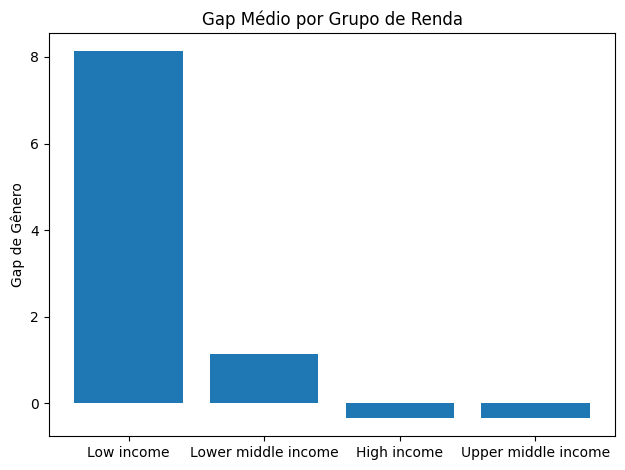

In [274]:
gap_income = merged_df.groupby("IncomeGroup")["Gender Gap"].mean().reset_index()
gap_income = gap_income.sort_values("Gender Gap", ascending=False)
plt.figure()
plt.bar(gap_income["IncomeGroup"], gap_income["Gender Gap"])
plt.title("Gap Médio por Grupo de Renda")
plt.ylabel("Gap de Gênero")
plt.tight_layout()
plt.show()

## 2.8 Evolução da média global de diferença de gênero

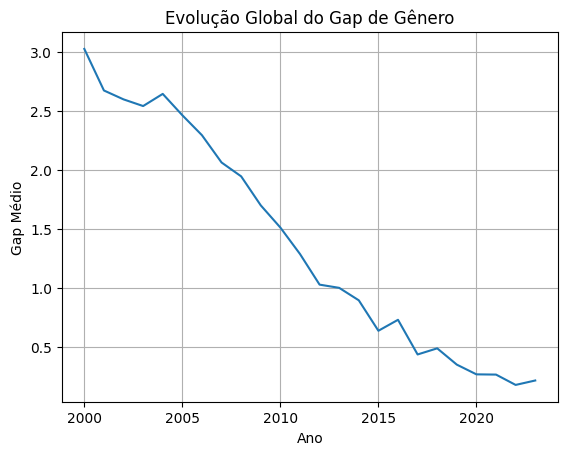

In [277]:
convergence = merged_df.groupby("Year")["Gender Gap"].mean().reset_index()

plt.figure()
plt.plot(convergence["Year"], convergence["Gender Gap"])
plt.title("Evolução Global do Gap de Gênero")
plt.xlabel("Ano")
plt.ylabel("Gap Médio")
plt.grid(True)
plt.show()

## Importante:
Demonstra que a alfabetização primária tem convergido para um cenário mais igual

# 2.9 Diferença na média de alfabetização primária feminina dentro de países da mesma região

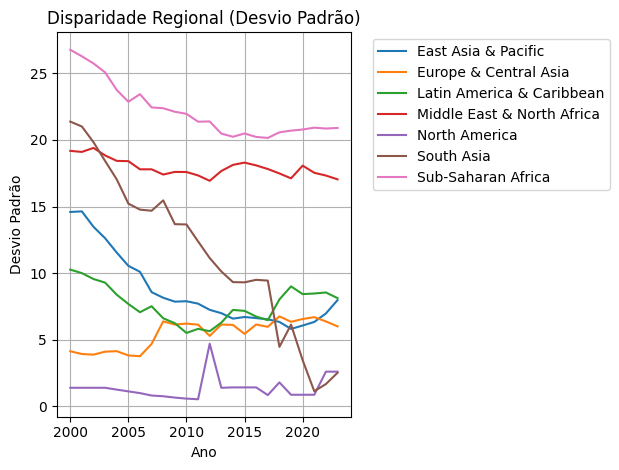

In [276]:
plt.figure()

for region in regional_dispersion["Region"].unique():
    df_plot = regional_dispersion[regional_dispersion["Region"] == region]
    plt.plot(df_plot["Year"], df_plot["Female Completion Rate"], label=region)

plt.title("Disparidade Regional (Desvio Padrão)")
plt.xlabel("Ano")
plt.ylabel("Desvio Padrão")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.tight_layout() 
plt.show()

Destaca-se a acelerada curva do Sul asiático, que se tornou uma região com taxas mais homogêmeas

Enquanto a África Subsaariana, que já era a região com mais países de baixa renda, demonstrou redução, 

mas ainda é a com maior disparidade regional, seguida pelo Oriente Médio e Norte da África

# 3 - Conclusão

A análise dos dados evidencia avanços consistentes na taxa de conclusão da educação primária feminina em escala global, especialmente a partir dos anos 2000, 
indicando esforços internacionais bem-sucedidos na ampliação do acesso à educação básica. No entanto, esses avanços não ocorreram de forma homogênea. Persistem
regiões que não garantem acesso amplo a Educação Básica para sua população, com destaque para contextos de baixa renda e áreas afetadas por instabilidade política, 
onde tanto os níveis de alfabetização da população como um todo quanto a desigualdade de gênero ainda são desafios relevantes.

A diferença de alfabetização primária entre homens e mulheres, embora tenha diminuído em diversas partes do mundo, continua presente em países
com menor desenvolvimento socioeconômico, sugerindo que barreiras culturais, institucionais e estruturais ainda limitam o acesso igualitário à educação. 
Ao mesmo tempo, a análise de disparidade regional revela que, mesmo dentro de uma mesma região, há grande heterogeneidade, o que reforça a necessidade de políticas públicas contextualizadas.